<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Aishwarya_12_models_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np


In [15]:
df = pd.read_excel('/content/drive/MyDrive/Aishwarya thesis clean dataset 27725.xlsx')

In [16]:
df

,name,age,gender,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,1wk kv,1wk axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,44.25,10
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,44.25,70
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,45.00,5
...,...,...,...,...,...,...,...,...,...,...,...,...
102,kamalamma,61,F,43.00,43.50,100,43.00,43.75,170,43.00,43.50,180
103,gundamma,54,F,45.75,46.25,30,45.75,47.00,5,46.25,45.75,15
104,sakamma,67,F,45.25,46.00,135,44.25,45.50,155,45.25,45.75,150
105,kenchangowda patil,61,M,46.00,46.50,40,46.25,48.00,5,46.25,47.00,30


In [24]:
df.columns

Index(['name', 'age', 'gender', 'preop kh', 'preop kv', 'preop axis',
       'postop kh', 'postop kv', 'postop axis', '1wk kh', '1wk kv',
       '1wk axis'],
      dtype='object')

In [28]:
dfclean = df.drop(['name', 'gender'], axis=1)
dfclean

,age,preop kh,preop kv,preop axis,postop kh,postop kv,postop axis,1wk kh,1wk kv,1wk axis
0,60,43.50,44.00,90,43.25,44.75,10,43.75,44.25,10
1,64,44.25,44.50,45,41.25,44.50,70,41.75,44.25,70
2,62,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,70,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
4,58,44.25,44.75,85,44.50,45.50,40,44.25,45.00,5
...,...,...,...,...,...,...,...,...,...,...
102,61,43.00,43.50,100,43.00,43.75,170,43.00,43.50,180
103,54,45.75,46.25,30,45.75,47.00,5,46.25,45.75,15
104,67,45.25,46.00,135,44.25,45.50,155,45.25,45.75,150
105,61,46.00,46.50,40,46.25,48.00,5,46.25,47.00,30


In [37]:
dfclean['preop kh'].corr(dfclean['postop kh']),dfclean['preop kv'].corr(dfclean['postop kv']), dfclean['preop axis'].corr(dfclean['postop axis'])


(np.float64(0.7656192611629506),
 np.float64(0.7165671809134555),
 np.float64(0.2335102044592344))

In [38]:
dfclean['preop kh'].corr(dfclean['1wk kh']),dfclean['preop kv'].corr(dfclean['1wk kv']), dfclean['preop axis'].corr(dfclean['1wk axis'])


(np.float64(0.8110153868969014),
 np.float64(0.8057355838416216),
 np.float64(0.5090351424667395))

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh']]
y = dfclean['postop kh']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model1.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model1.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model1.coef_})")
print(f"model.intercept_: ({model1.intercept_})")
print(f"Simple Linear Regression Equation: y = {model1.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 0.6117825625849665
Simple Linear Regression Mean Squared Error: 0.5334619680444118
Simple Linear Regression Root Mean Squared error: 0.7303848081966189
Simple Linear Regression R-squared: 0.8089651107266624
model.coef_: ([0.87010601])
model.intercept_: (5.3974743160703085)
Simple Linear Regression Equation: y = 0.8701x + 5.3975


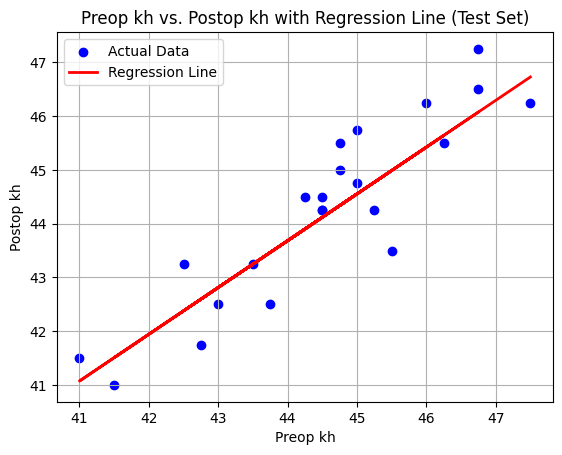

In [85]:
import matplotlib.pyplot as plt

# Plot the actual data points from the test set
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

# Plot the regression line using the test data
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

# Add labels and title
plt.title('Preop kh vs. Postop kh with Regression Line (Test Set)')
plt.xlabel('Preop kh')
plt.ylabel('Postop kh')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kv']]
y = dfclean['postop kv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model2 = LinearRegression()
model2.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model2.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model2.coef_})")
print(f"model.intercept_: ({model2.intercept_})")
print(f"Simple Linear Regression Equation: y = {model2.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 0.8526138128576044
Simple Linear Regression Mean Squared Error: 1.2646515137564467
Simple Linear Regression Root Mean Squared error: 1.1245672562174513
Simple Linear Regression R-squared: 0.7370247489989548
model.coef_: ([0.85247592])
model.intercept_: (7.179751192496248)
Simple Linear Regression Equation: y = 0.8525x + 7.1798


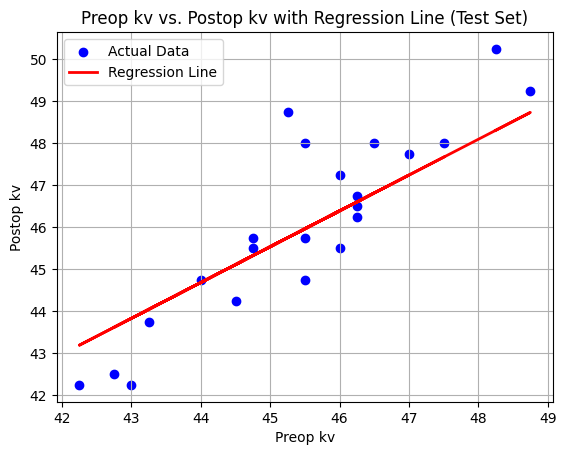

In [88]:
import matplotlib.pyplot as plt

# Plot the actual data points from the test set
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

# Plot the regression line using the test data
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

# Add labels and title
plt.title('Preop kv vs. Postop kv with Regression Line (Test Set)')
plt.xlabel('Preop kv')
plt.ylabel('Postop kv')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop axis']]
y = dfclean['postop axis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model3 = LinearRegression()
model3.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model3.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model3.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model3.coef_})")
print(f"model.intercept_: ({model3.intercept_})")
print(f"Simple Linear Regression Equation: y = {model3.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 59.95228747430008
Simple Linear Regression Mean Squared Error: 4255.382537957445
Simple Linear Regression Root Mean Squared error: 65.2332931711825
Simple Linear Regression R-squared: 0.08258122566975379
model.coef_: ([0.22028116])
model.intercept_: (79.947421726215)
Simple Linear Regression Equation: y = 0.2203x + 79.9474


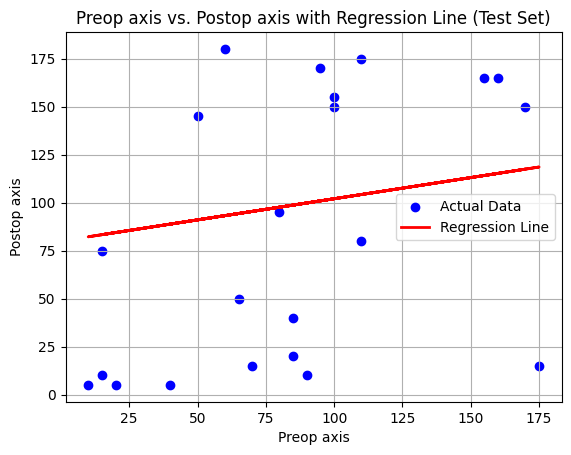

In [90]:
import matplotlib.pyplot as plt

# Plot the actual data points from the test set
plt.scatter(X_test, y_test, color='blue', label='Actual Data')

# Plot the regression line using the test data
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

# Add labels and title
plt.title('Preop axis vs. Postop axis with Regression Line (Test Set)')
plt.xlabel('Preop axis')
plt.ylabel('Postop axis')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv']]
y = dfclean['postop kh']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model4 = LinearRegression()
model4.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model4.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model4.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model4.coef_})")
print(f"model.intercept_: ({model4.intercept_})")
print(f"Simple Linear Regression Equation: y = {model4.coef_[0]:.4f}x + {model4.coef_[1]:.4f} + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 0.5495887832515784
Simple Linear Regression Mean Squared Error: 0.4607912084950421
Simple Linear Regression Root Mean Squared error: 0.6788160343532275
Simple Linear Regression R-squared: 0.8349888037648274
model.coef_: ([0.63691435 0.27641195])
model.intercept_: (3.2180540946522456)
Simple Linear Regression Equation: y = 0.6369x + 0.2764 + 3.2181


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


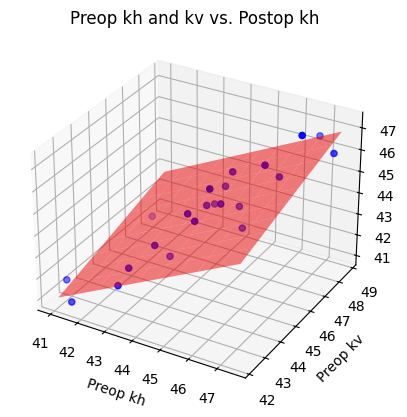

In [97]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the actual data
ax.scatter(X_test['preop kh'], X_test['preop kv'], y_test, color='blue', label='Actual Data')

# Create a meshgrid for the regression plane
x_surf, y_surf = np.meshgrid(np.linspace(X_test['preop kh'].min(), X_test['preop kh'].max(), 10),
                           np.linspace(X_test['preop kv'].min(), X_test['preop kv'].max(), 10))
z_surf = model4.predict(np.c_[x_surf.ravel(), y_surf.ravel()]).reshape(x_surf.shape)


# Plot the regression plane
ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.5, label='Regression Plane')

# Add labels and title
ax.set_xlabel('Preop kh')
ax.set_ylabel('Preop kv')
ax.set_zlabel('Postop kh')
ax.set_title('Preop kh and kv vs. Postop kh')

plt.show()

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv']]
y = dfclean['postop kv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model5 = LinearRegression()
model5.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model5.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model5.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model5.coef_})")
print(f"model.intercept_: ({model5.intercept_})")
print(f"Simple Linear Regression Equation: y = {model5.coef_[0]:.4f}x + {model5.coef_[1]:.4f} + {intercept:.4f}")

#print(f"Simple Linear Regression Equation: y = {model5.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 0.8726266871891752
Simple Linear Regression Mean Squared Error: 1.3418130153047505
Simple Linear Regression Root Mean Squared error: 1.1583665289124814
Simple Linear Regression R-squared: 0.7209795657871704
model.coef_: ([0.1927305 0.660465 ])
model.intercept_: (7.321573724830131)
Simple Linear Regression Equation: y = 0.1927x + 0.6605 + 7.3216


In [126]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv']]
y = dfclean['postop axis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model6 = LinearRegression()
model6.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model6.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model6.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model6.coef_})")
print(f"model.intercept_: ({model6.intercept_})")

print(f"Simple Linear Regression Equation: y = {model6.coef_[0]:.4f}x + {model6.coef_[1]:.4f} + {intercept:.4f}")

#print(f"Simple Linear Regression Equation: y = {model6.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 60.69246559635155
Simple Linear Regression Mean Squared Error: 4426.383671303878
Simple Linear Regression Root Mean Squared error: 66.53107297574479
Simple Linear Regression R-squared: 0.045715057055199626
model.coef_: ([ 10.8698367  -15.30115514])
model.intercept_: (311.5823912994867)
Simple Linear Regression Equation: y = 10.8698x + -15.3012 + 311.5824


In [128]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv', 'preop axis']]
y = dfclean['postop kh']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model7 = LinearRegression()
model7.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model7.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model7.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model7.coef_})")
print(f"model.intercept_: ({model7.intercept_})")

print(f"Simple Linear Regression Equation: y = {model7.coef_[0]:.4f}x + {model7.coef_[1]:.4f} + {model7.coef_[2]:.4f} + {intercept:.4f}")

#print(f"Simple Linear Regression Equation: y = {model7.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 0.5549512702240911
Simple Linear Regression Mean Squared Error: 0.47500717147940114
Simple Linear Regression Root Mean Squared error: 0.6892076403228574
Simple Linear Regression R-squared: 0.829898009898891
model.coef_: ([ 0.66427635  0.24871093 -0.00149085])
model.intercept_: (3.3935955922472942)
Simple Linear Regression Equation: y = 0.6643x + 0.2487 + -0.0015 + 3.3936


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv', 'preop axis']]
y = dfclean['postop kv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model8 = LinearRegression()
model8.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model8.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model8.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model8.coef_})")
print(f"model.intercept_: ({model8.intercept_})")

print(f"Simple Linear Regression Equation: y = {model8.coef_[0]:.4f}x + {model8.coef_[1]:.4f} + {model8.coef_[2]:.4f} + {intercept:.4f}")


#print(f"Simple Linear Regression Equation: y = {model8.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 0.9127841276189514
Simple Linear Regression Mean Squared Error: 1.471740718032534
Simple Linear Regression Root Mean Squared error: 1.2131532129259412
Simple Linear Regression R-squared: 0.6939620278605854
model.coef_: ([ 0.2666867   0.58559246 -0.00402958])
model.intercept_: (7.7960413834520566)
Simple Linear Regression Equation: y = 0.2667x + 0.5856 + -0.0040 + 7.7960


In [130]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv', 'preop axis']]
y = dfclean['postop axis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model9 = LinearRegression()
model9.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model9.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model9.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model9.coef_})")
print(f"model.intercept_: ({model9.intercept_})")

print(f"Simple Linear Regression Equation: y = {model9.coef_[0]:.4f}x + {model9.coef_[1]:.4f} + {model9.coef_[2]:.4f} + {intercept:.4f}")


#print(f"Simple Linear Regression Equation: y = {model9.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 57.04436224997778
Simple Linear Regression Mean Squared Error: 3960.0802762074686
Simple Linear Regression Root Mean Squared error: 62.92916872331517
Simple Linear Regression R-squared: 0.14624549947242116
model.coef_: ([  7.36540115 -11.75329873   0.19094281])
model.intercept_: (289.09960759108674)
Simple Linear Regression Equation: y = 7.3654x + -11.7533 + 0.1909 + 289.0996


In [131]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv', 'preop axis', 'age']]
y = dfclean['postop kh']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model10 = LinearRegression()
model10.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model10.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model10.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model10.coef_})")
print(f"model.intercept_: ({model10.intercept_})")

print(f"Simple Linear Regression Equation: y = {model10.coef_[0]:.4f}x + {model10.coef_[1]:.4f} + {model10.coef_[2]:.4f} + {model10.coef_[3]:.4f} + {intercept:.4f}")


#print(f"Simple Linear Regression Equation: y = {model10.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 0.49398795781300464
Simple Linear Regression Mean Squared Error: 0.4316859199479401
Simple Linear Regression Root Mean Squared error: 0.6570280967720787
Simple Linear Regression R-squared: 0.8454115253606082
model.coef_: ([ 0.59275385  0.3059995  -0.00205763  0.05727168])
model.intercept_: (0.27680459246344213)
Simple Linear Regression Equation: y = 0.5928x + 0.3060 + -0.0021 + 0.0573 + 0.2768


In [132]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv', 'preop axis', 'age']]
y = dfclean['postop kv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model11 = LinearRegression()
model11.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model11.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model11.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model11.coef_})")
print(f"model.intercept_: ({model11.intercept_})")

print(f"Simple Linear Regression Equation: y = {model11.coef_[0]:.4f}x + {model11.coef_[1]:.4f} + {model11.coef_[2]:.4f} + {model11.coef_[3]:.4f} + {intercept:.4f}")


#print(f"Simple Linear Regression Equation: y = {model11.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 0.9547138894622365
Simple Linear Regression Mean Squared Error: 1.4972659147760445
Simple Linear Regression Root Mean Squared error: 1.2236281766844226
Simple Linear Regression R-squared: 0.6886542454814402
model.coef_: ([ 0.18580061  0.65038114 -0.00467057  0.06476959])
model.intercept_: (4.271205724345684)
Simple Linear Regression Equation: y = 0.1858x + 0.6504 + -0.0047 + 0.0648 + 4.2712


In [133]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Define features (X) and target (y)
X = dfclean[['preop kh', 'preop kv', 'preop axis', 'age']]
y = dfclean['postop axis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the multiple linear regression model
model12 = LinearRegression()
model12.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model12.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rms = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
intercept = model12.intercept_

print(f"Simple Linear Regression Mean absolute error: {mae}")
print(f"Simple Linear Regression Mean Squared Error: {mse}")
print(f"Simple Linear Regression Root Mean Squared error: {rms}")
print(f"Simple Linear Regression R-squared: {r2}")
print(f"model.coef_: ({model12.coef_})")
print(f"model.intercept_: ({model12.intercept_})")

print(f"Simple Linear Regression Equation: y = {model12.coef_[0]:.4f}x + {model12.coef_[1]:.4f} + {model12.coef_[2]:.4f} + {model12.coef_[3]:.4f} + {intercept:.4f}")


#print(f"Simple Linear Regression Equation: y = {model12.coef_[0]:.4f}x + {intercept:.4f}")


Simple Linear Regression Mean absolute error: 57.558284637727
Simple Linear Regression Mean Squared Error: 3990.359147516114
Simple Linear Regression Root Mean Squared error: 63.16928959166878
Simple Linear Regression R-squared: 0.13971767153772885
model.coef_: ([  6.16747033 -10.79377219   0.18144976   0.95924386])
model.intercept_: (236.89645199904862)
Simple Linear Regression Equation: y = 6.1675x + -10.7938 + 0.1814 + 0.9592 + 236.8965


## Results and Analysis

Here is a summary of the performance of the different regression models:

| Model | Target Variable | Features | R-squared |
|---|---|---|---|
| Model 1 | postop kh | preop kh | 0.809 |
| Model 2 | postop kv | preop kv | 0.737 |
| Model 3 | postop axis | preop axis | 0.083 |
| Model 4 | postop kh | preop kh, preop kv | 0.835 |
| Model 5 | postop kv | preop kh, preop kv | 0.721 |
| Model 6 | postop axis | preop kh, preop kv | 0.046 |
| Model 7 | postop kh | preop kh, preop kv, preop axis | 0.830 |
| Model 8 | postop kv | preop kh, preop kv, preop axis | 0.694 |
| Model 9 | postop axis | preop kh, preop kv, preop axis | 0.146 |
| Model 10 | postop kh | preop kh, preop kv, preop axis, age | 0.845 |
| Model 11 | postop kv | preop kh, preop kv, preop axis, age | 0.689 |
| Model 12 | postop axis | preop kh, preop kv, preop axis, age | 0.140 |

### Analysis

*   **Predicting `postop kh`**: The models predicting `postop kh` consistently perform the best, with the highest R-squared values. Model 10, which includes all features, has the highest R-squared value of 0.845, indicating that it explains about 84.5% of the variance in `postop kh`.
*   **Predicting `postop kv`**: The models predicting `postop kv` have moderate performance, with R-squared values ranging from 0.689 to 0.737.
*   **Predicting `postop axis`**: The models predicting `postop axis` have very low R-squared values, suggesting that the selected features are not good predictors for `postop axis`.
*   **Feature Importance**: Adding more features generally improves the R-squared value for predicting `postop kh` and `postop kv`, but the improvement is not always significant. For `postop axis`, adding more features does not seem to help much.
*   **Best Model**: Based on the R-squared values, **Model 10** is the best performing model for predicting `postop kh`.

In [134]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(dfclean[['preop kh', 'preop kv']])

# Split the data into training and testing sets
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, dfclean['postop kh'], test_size=0.2, random_state=42)

# Create and train the linear regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Make predictions on the test data
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate the model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression Mean Squared Error: {mse_poly}")
print(f"Polynomial Regression R-squared: {r2_poly}")

Polynomial Regression Mean Squared Error: 0.5361150661728643
Polynomial Regression R-squared: 0.8080150255517844


In [135]:
from sklearn.preprocessing import PolynomialFeatures

# Create interaction features
interaction = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_interaction = interaction.fit_transform(dfclean[['preop kh', 'preop kv']])

# Split the data into training and testing sets
X_train_interaction, X_test_interaction, y_train, y_test = train_test_split(X_interaction, dfclean['postop kh'], test_size=0.2, random_state=42)

# Create and train the linear regression model
interaction_model = LinearRegression()
interaction_model.fit(X_train_interaction, y_train)

# Make predictions on the test data
y_pred_interaction = interaction_model.predict(X_test_interaction)

# Evaluate the model
mse_interaction = mean_squared_error(y_test, y_pred_interaction)
r2_interaction = r2_score(y_test, y_pred_interaction)

print(f"Interaction Features Mean Squared Error: {mse_interaction}")
print(f"Interaction Features R-squared: {r2_interaction}")

Interaction Features Mean Squared Error: 0.4298485189777125
Interaction Features R-squared: 0.8460695060826171


## Conclusions

Here is a summary of the performance of the different regression models:

| Model | Target Variable | Features | R-squared |
|---|---|---|---|
| Model 1 | postop kh | preop kh | 0.809 |
| Model 2 | postop kv | preop kv | 0.737 |
| Model 3 | postop axis | preop axis | 0.083 |
| Model 4 | postop kh | preop kh, preop kv | 0.835 |
| Model 5 | postop kv | preop kh, preop kv | 0.721 |
| Model 6 | postop axis | preop kh, preop kv | 0.046 |
| Model 7 | postop kh | preop kh, preop kv, preop axis | 0.830 |
| Model 8 | postop kv | preop kh, preop kv, preop axis | 0.694 |
| Model 9 | postop axis | preop kh, preop kv, preop axis | 0.146 |
| Model 10 | postop kh | preop kh, preop kv, preop axis, age | 0.845 |
| Model 11 | postop kv | preop kh, preop kv, preop axis, age | 0.689 |
| Model 12 | postop axis | preop kh, preop kv, preop axis, age | 0.140 |

### Analysis

*   **Predicting `postop kh`**: The models predicting `postop kh` consistently perform the best, with the highest R-squared values. Model 10, which includes all features, has the highest R-squared value of 0.845, indicating that it explains about 84.5% of the variance in `postop kh`.
*   **Predicting `postop kv`**: The models predicting `postop kv` have moderate performance, with R-squared values ranging from 0.689 to 0.737.
*   **Predicting `postop axis`**: The models predicting `postop axis` have very low R-squared values, suggesting that the selected features are not good predictors for `postop axis`.
*   **Feature Importance**: Adding more features generally improves the R-squared value for predicting `postop kh` and `postop kv`, but the improvement is not always significant. For `postop axis`, adding more features does not seem to help much.
*   **Best Model**: Based on the R-squared values, **Model 10** is the best performing model for predicting `postop kh`.